## Proyek Metode Komputasi
### Kalkulasi Magnitudo
Program meghitung magnitudo pada suatu gempa dari data seismik yang direkam pada seismometer

1. Magnitudo Lokal (ML)    
![ML](ml.png)    
A = amplitudo maksimum (biasanya setelah dikoreksi ke instrumen standar)    
A0(Δ) = fungsi koreksi jarak (epicentral distance) dari stasiun ke gempa.
2. Magnitudo Body (MB)    
![ML](mb.png)   
A = amplitudo ground motion (µm)    
T = periode dari gelombang yang diukur (s)  
Q(Δ,h) = koreksi fungsi jarak epicentral Δ (dalam derajat) dan kedalaman fokus ℎ

3. Magnitudo Surface (MS)    
![ML](ms.png)   
A = amplitudo maksimum gelombang permukaan (vektor hasil jumlah dua komponen horizontal) dalam µm.  
T = periode yang sesuai (umumnya ≈ 20 s; tradisional MS mengukur Rayleigh wave sekitar 20 s).   
Δ = jarak epicentral dalam derajat (°).




=== MEMUAT DATA MSEED ===
Data dari: GE.MARCO.HHZ
Durasi: 1803.42
Sampling rate: 100.0 Hz

=== MENGHITUNG PARAMETER ===
Amplitudo maksimum (counts): 5.03e+04
Jarak episentral: 0.28° (31.3 km)
Periode dominan (T): 11.20 detik

=== HASIL PERHITUNGAN MAGNITUDE ===
ML (Lokal)                = 7.44
MS (Gelombang Permukaan)  = 6.04
MB (Gelombang Badan)      = 4.42
=== MENAMPILKAN WAVEFORM ===


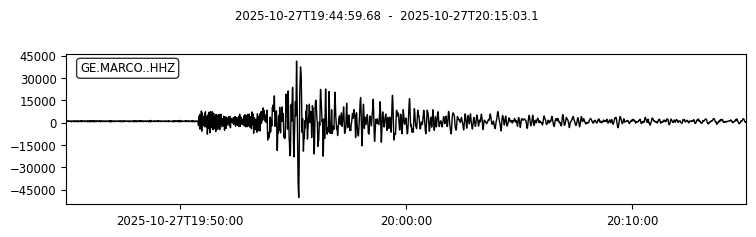

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from obspy import read
from obspy.geodetics import locations2degrees


# Kelas 1: SeismicData — Membaca dan memproses data waveform
class SeismicData:
    def __init__(self, mseed_file, event_lat, event_lon, station_lat, station_lon):
        self.mseed_file = mseed_file
        self.event_lat = event_lat
        self.event_lon = event_lon
        self.station_lat = station_lat
        self.station_lon = station_lon
        self.trace = None
        self.stats = None
        self.amplitude = None
        self.delta_deg = None
        self.delta_km = None
        self.dominant_T = None

    def load_data(self):
        """Membaca file MiniSEED dan menyimpan trace pertama"""
        self.trace = read(self.mseed_file)[0]
        self.stats = self.trace.stats
        print(f"Data dari: {self.stats.network}.{self.stats.station}.{self.stats.channel}")
        print(f"Durasi: {self.trace.stats.endtime - self.trace.stats.starttime}")
        print(f"Sampling rate: {self.stats.sampling_rate} Hz")

    def compute_amplitude(self):
        """Menghitung amplitudo maksimum"""
        self.amplitude = np.max(np.abs(self.trace.data))
        print(f"Amplitudo maksimum (counts): {self.amplitude:.2e}")
        return self.amplitude

    def compute_distance(self):
        """Menghitung jarak episentral (dalam derajat dan km)"""
        self.delta_deg = locations2degrees(
            self.event_lat, self.event_lon, self.station_lat, self.station_lon
        )
        self.delta_km = self.delta_deg * 111.19
        print(f"Jarak episentral: {self.delta_deg:.2f}° ({self.delta_km:.1f} km)")
        return self.delta_deg, self.delta_km

    def compute_dominant_period(self):
        """Mengestimasi periode dominan sinyal menggunakan FFT"""
        fft = np.fft.rfft(self.trace.data)
        freqs = np.fft.rfftfreq(len(self.trace.data), d=1 / self.stats.sampling_rate)
        dominant_freq = freqs[np.argmax(np.abs(fft[1:])) + 1]
        self.dominant_T = 1 / dominant_freq if dominant_freq != 0 else 1.0
        print(f"Periode dominan (T): {self.dominant_T:.2f} detik")
        return self.dominant_T

    def plot_trace(self):
        """Menampilkan plot waveform"""
        self.trace.plot()


# Kelas 2: MagnitudeCalculator — Menghitung ML, MS, dan MB
class MagnitudeCalculator:
    def __init__(self, amplitude, period, delta_km, delta_deg):
        self.A = amplitude
        self.T = period
        self.delta_km = delta_km
        self.delta_deg = delta_deg

    def calc_ML(self):
        """Menghitung magnitudo lokal (ML)"""
        ML = np.log10(self.A) + 0.018 * self.delta_km + 2.17
        return ML

    def calc_MS(self):
        """Menghitung magnitudo gelombang permukaan (MS)"""
        MS = np.log10(self.A / self.T) + 1.66 * np.log10(self.delta_deg) + 3.3
        return MS

    def calc_MB(self):
        """Menghitung magnitudo gelombang badan (MB)"""
        MB = np.log10(self.A / self.T) + 0.00301 * self.delta_deg + 0.77
        return MB


# Kelas 3: EarthquakeMagnitudeApp — Alur utama program
class EarthquakeMagnitudeApp:
    def __init__(self, mseed_file, event_lat, event_lon, station_lat, station_lon):
        self.data = SeismicData(mseed_file, event_lat, event_lon, station_lat, station_lon)
        self.results = {}

    def run(self):
        """Menjalankan seluruh tahapan perhitungan"""
        print("\n=== MEMUAT DATA MSEED ===")
        self.data.load_data()

        print("\n=== MENGHITUNG PARAMETER ===")
        A = self.data.compute_amplitude()
        delta_deg, delta_km = self.data.compute_distance()
        T = self.data.compute_dominant_period()

        mag_calc = MagnitudeCalculator(A, T, delta_km, delta_deg)
        ML_val = mag_calc.calc_ML()
        MS_val = mag_calc.calc_MS()
        MB_val = mag_calc.calc_MB()

        self.results = {"ML": ML_val, "MS": MS_val, "MB": MB_val}

        print("\n=== HASIL PERHITUNGAN MAGNITUDE ===")
        print(f"ML (Lokal)                = {ML_val:.2f}")
        print(f"MS (Gelombang Permukaan)  = {MS_val:.2f}")
        print(f"MB (Gelombang Badan)      = {MB_val:.2f}")

        print("=== MENAMPILKAN WAVEFORM ===")
        self.data.plot_trace()


# EKSEKUSI PROGRAM UTAMA
if __name__ == "__main__":
    # --- Input awal ---
    mseed_file = "TURKI.mseed"  # ubah sesuai nama file kamu
    event_lat, event_lon = -7.5, 110.2
    station_lat, station_lon = -7.7, 110.4

    # --- Jalankan aplikasi ---
    app = EarthquakeMagnitudeApp(mseed_file, event_lat, event_lon, station_lat, station_lon)
    app.run()
